In [20]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
df = pd.read_csv('StudentsPerformance.csv') 
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
df['race/ethnicity'].value_counts()

group C    319
group D    262
group B    190
group E    140
group A     89
Name: race/ethnicity, dtype: int64

In [23]:
df.info() # make sure no nul values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Boxplot

#### Boxplot 




** Box Plot Summary:

* Box: shows the interquartile range (IQR) — from Q1 (25th percentile) to Q3 (75th percentile)

   * Median: line inside the box (50th percentile)

  *  Whiskers: extend to the smallest and largest values within 1.5 × IQR

 *   Outliers: any points beyond the whiskers (i.e., outside Q1 - 1.5×IQR or Q3 + 1.5×IQR)

Outlier Calculation:

Let’s say:

    Q1 = 20

    Q3 = 40
    Then:

    IQR = Q3 - Q1 = 20

    Lower bound = Q1 − 1.5 × IQR = 20 − 30 = −10

    Upper bound = Q3 + 1.5 × IQR = 40 + 30 = 70

👉 So, any value < -10 or > 70 is an outlier.



##### Scenerion: You have 5 people with a bachelor’s degree, and each person has scores in 3 subjects — say: Math, Physics, and English.

In [24]:
import pandas as pd

data = {
    'Name': ['A', 'B', 'C', 'D', 'E'],
    'Math':    [80, 85, 95, 70, 60],
    'Physics': [78, 82, 96, 65, 68],
    'English': [88, 90, 85, 60, 75]
}

df1 = pd.DataFrame(data)


In [25]:
#Step 1: Convert to long format (for box plot)
#Box plots work best when your data is in "long format" (i.e., melted), not wide.

df_melted = df1.melt(id_vars='Name', var_name='Subject', value_name='Score')


In [26]:
df_melted

,Name,Subject,Score
0,A,Math,80
1,B,Math,85
2,C,Math,95
3,D,Math,70
4,E,Math,60
5,A,Physics,78
6,B,Physics,82
7,C,Physics,96
8,D,Physics,65
9,E,Physics,68


/tmp/ipykernel_1252591/691398623.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Subject', y='Score', palette='Set2')


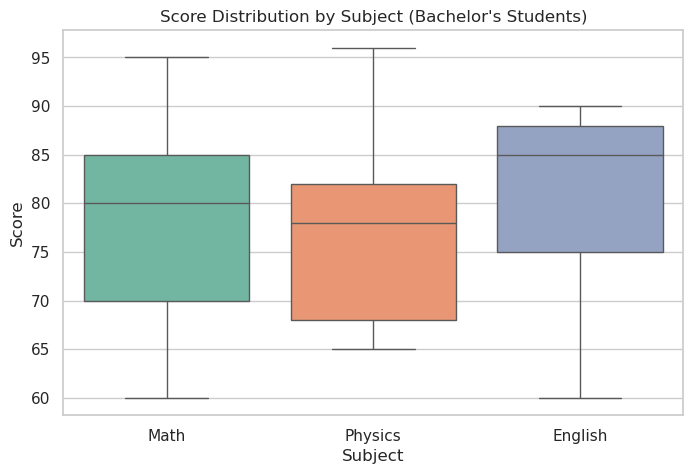

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))
sns.boxplot(data=df_melted, x='Subject', y='Score', palette='Set2')
plt.title("Score Distribution by Subject (Bachelor's Students)")
plt.show()


## 📦 Box Plot Terms Explained (Using Math Scores)

Given 5 math scores:  
`[60, 70, 80, 85, 95]` (sorted)

### 🔢 Quartiles and IQR

- **Q1 (25th percentile)**: 70  
- **Q2 (Median, 50th percentile)**: 80  
- **Q3 (75th percentile)**: 85  
- **IQR (Interquartile Range)** = Q3 − Q1 = 85 − 70 = **15**

### 📏 Whisker Boundaries (for Outlier Detection)

We use the IQR to define outlier bounds:

- **Lower bound** = Q1 − 1.5 × IQR = 70 − 22.5 = **47.5**
- **Upper bound** = Q3 + 1.5 × IQR = 85 + 22.5 = **107.5**

### 🚨 Outlier Rule

Any value:
- **< 47.5** or
- **> 107.5**

is considered an **outlier**.

➡️ In this example, all scores are within range → **No outliers**.

---

### 📊 Box Plot Summary

| Term      | Meaning                                |
|-----------|-----------------------------------------|
| Q1        | First quartile (25% of data below)     |
| Q2        | Median (50% of data below)             |
| Q3        | Third quartile (75% of data below)     |
| IQR       | Interquartile Range = Q3 − Q1          |
| Whiskers  | Extend to max/min within 1.5×IQR       |
| Outliers  | Points outside whisker boundaries      |

---

### 💡 Visual Notes

- The **box** spans from **Q1 to Q3**
- The **line** inside the box is the **median (Q2)**
- **Whiskers** extend to values within 1.5×IQR
- **Outliers** appear as dots beyond the whiskers


## 📦 Box Plot Example with Outlier

Let's analyze a set of math scores that contains an outlier:

### 🎓 Sample Math Scores:

2. **Quartiles**:
- **Q1 (25th percentile)** = 70  
- **Q2 (Median)** = (80 + 85) / 2 = **82.5**  
- **Q3 (75th percentile)** = 95  
- **IQR (Interquartile Range)** = Q3 − Q1 = 95 − 70 = **25**

3. **Outlier Thresholds**:
- **Lower Bound** = Q1 − 1.5 × IQR = 70 − 37.5 = **32.5**
- **Upper Bound** = Q3 + 1.5 × IQR = 95 + 37.5 = **132.5**

4. **Outliers**:
- Any value < 32.5 or > 132.5 is an outlier.
- In this case, **200** is greater than 132.5 → ✅ **Outlier detected!**

---

### 📊 Summary Table

| Term         | Value   |
|--------------|---------|
| Q1           | 70      |
| Q2 (Median)  | 82.5    |
| Q3           | 95      |
| IQR          | 25      |
| Lower Bound  | 32.5    |
| Upper Bound  | 132.5   |
| Outlier(s)   | **200** |

---

### 📦 Interpretation

In the box plot:
- The **box** spans from **Q1 to Q3**.
- A line in the box marks the **median (Q2)**.
- **Whiskers** extend to data within the non-outlier range (32.5 to 132.5).
- **Points beyond the whiskers**, like **200**, are plotted as **individual dots (outliers)**.

This helps us visually identify data points that are unusually high or low compared to the rest.


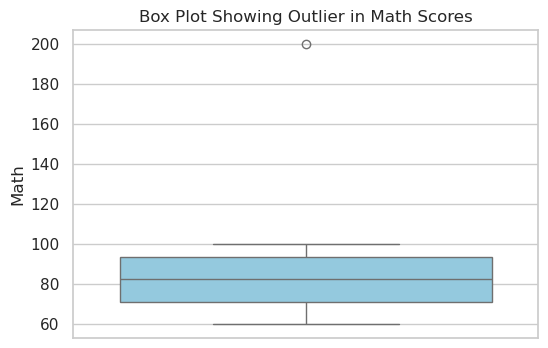

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample data with outlier
scores = [60, 65, 70, 75, 80, 85, 90, 95, 100, 200]
df2 = pd.DataFrame({'Math': scores})

# Create box plot
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6, 4))
sns.boxplot(data=df2, y='Math', color='skyblue')
plt.title('Box Plot Showing Outlier in Math Scores')
plt.show()


In [29]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

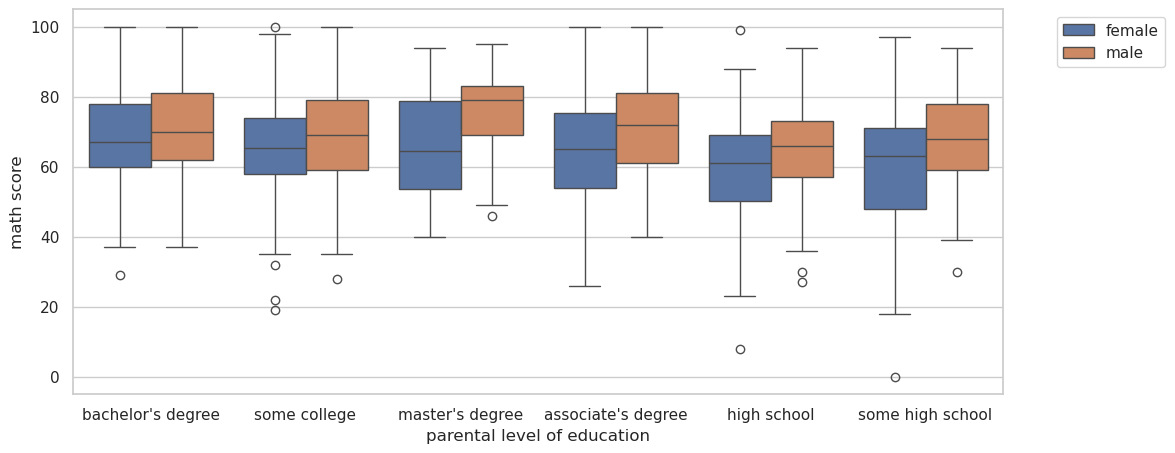

In [32]:
plt.figure(figsize = (12,5))
sns.boxplot(x = 'parental level of education', y = 'math score', data  = df, hue = 'gender')
plt.legend(bbox_to_anchor = (1.05,1))

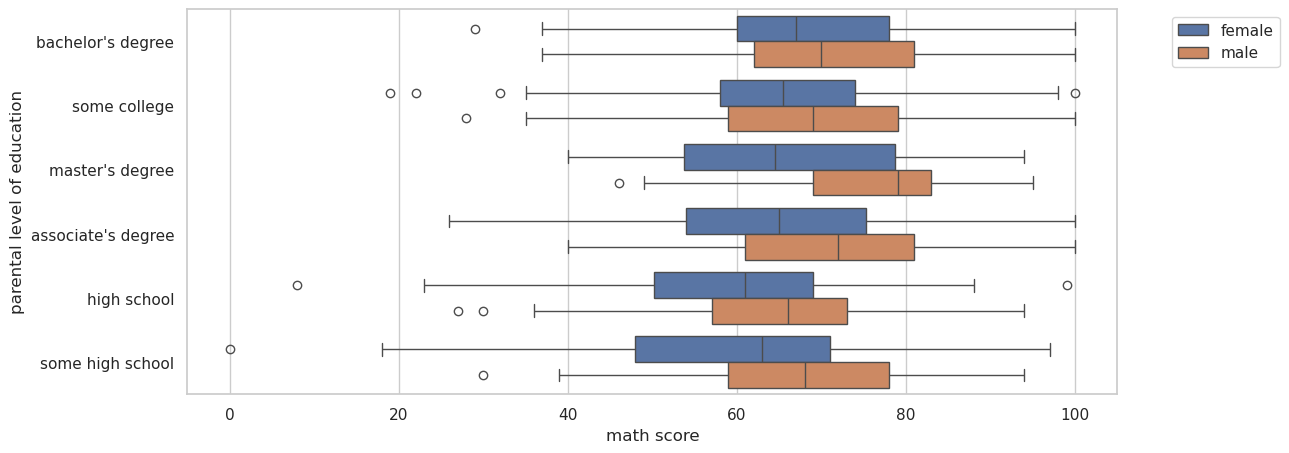

In [34]:
# Orientation: horizontal ( need to change the axis as well )
plt.figure(figsize = (12,5))
sns.boxplot(y = 'parental level of education', x = 'math score', data  = df, hue = 'gender', orient = 'h')
plt.legend(bbox_to_anchor = (1.05,1))

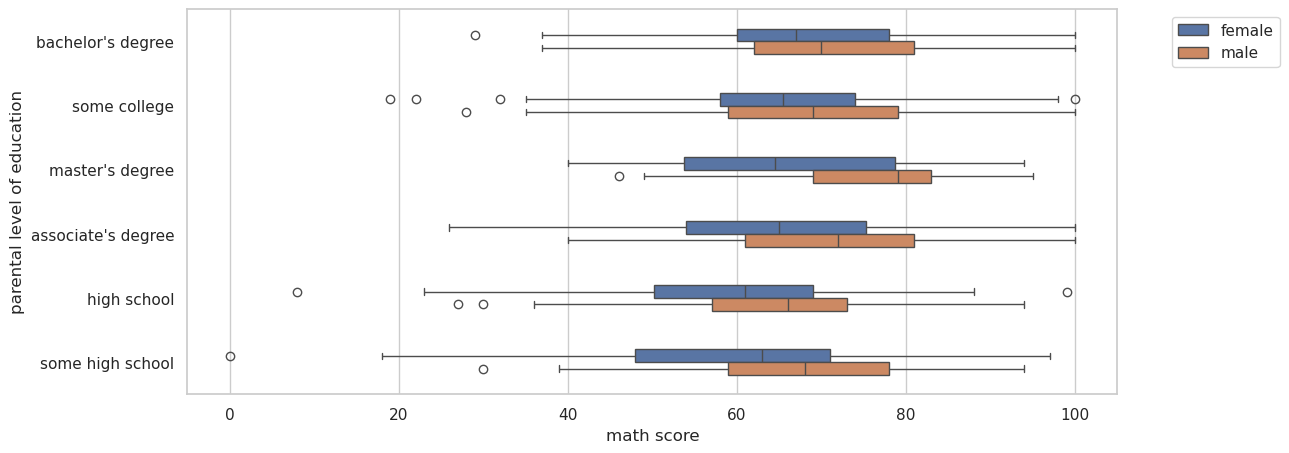

In [41]:
plt.figure(figsize = (12,5))
sns.boxplot(y = 'parental level of education', x = 'math score', data  = df, hue = 'gender', orient = 'h', width = 0.4)
plt.legend(bbox_to_anchor = (1.05,1))
# Drawback : we do not know number of data point in the box so we uses violin plots

### Violin plot

<Axes: xlabel='parental level of education', ylabel='math score'>

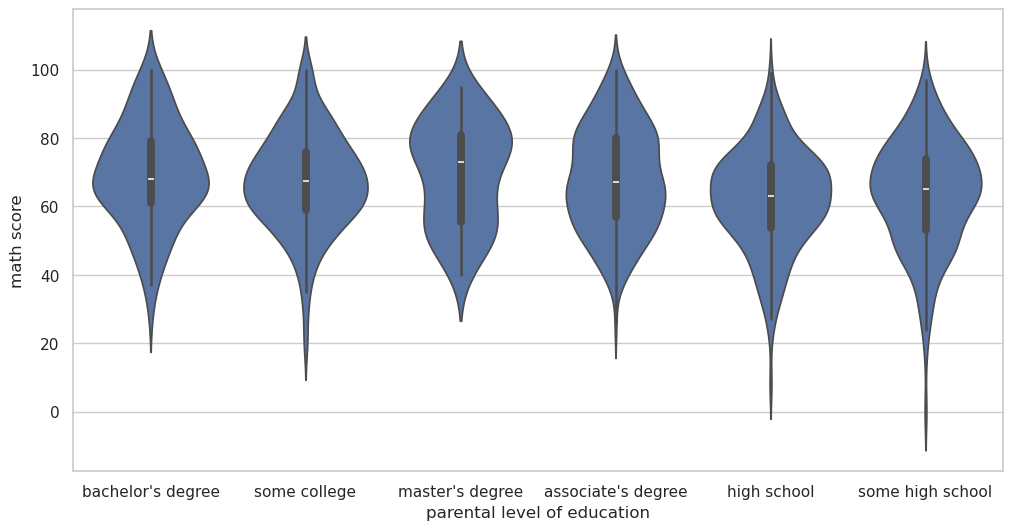

In [52]:
plt.figure(figsize = (12, 6))
sns.violinplot(x = 'parental level of education', y = 'math score', data  = df) 


<Axes: xlabel='parental level of education', ylabel='math score'>

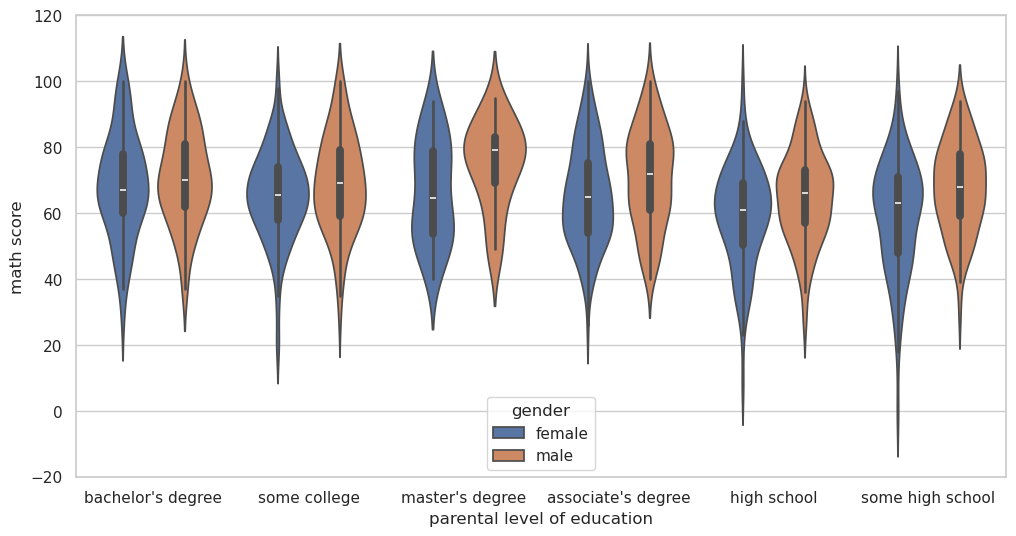

In [53]:
plt.figure(figsize = (12, 6))
sns.violinplot(x = 'parental level of education', y = 'math score', data  = df, hue = 'gender') # binary hue 


<Axes: xlabel='parental level of education', ylabel='math score'>

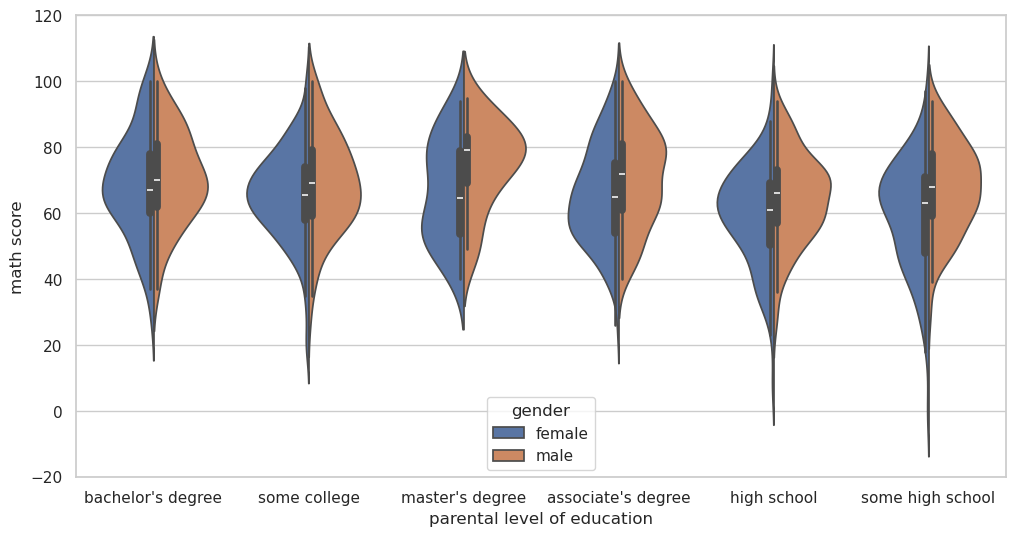

In [54]:
plt.figure(figsize = (12, 6))
sns.violinplot(x = 'parental level of education', y = 'math score', data  = df, hue = 'gender', split = 2) # binary hue 


<Axes: xlabel='parental level of education', ylabel='math score'>

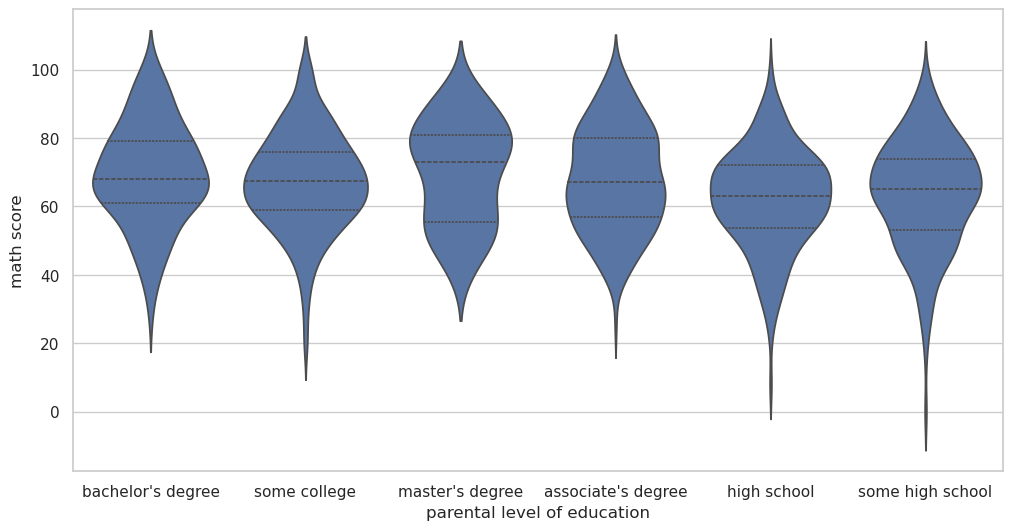

In [56]:
plt.figure(figsize = (12, 6))
sns.violinplot(x = 'parental level of education', y = 'math score', data  = df, inner = 'quartile') 


<Axes: xlabel='parental level of education', ylabel='math score'>

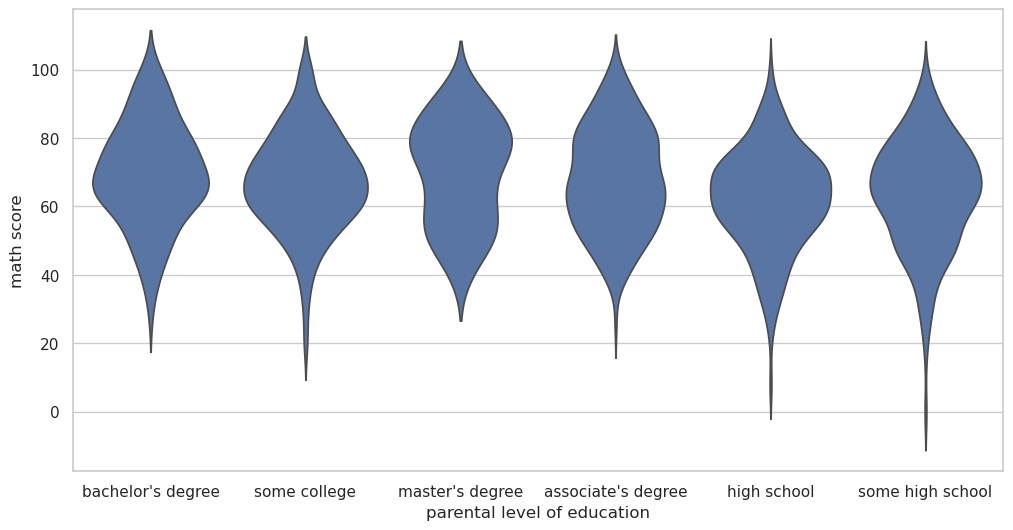

In [60]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='parental level of education',
    y='math score',
    data=df,
    inner=None
)


### swarm plot

<Axes: xlabel='writing score'>

/home/saji/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 55.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


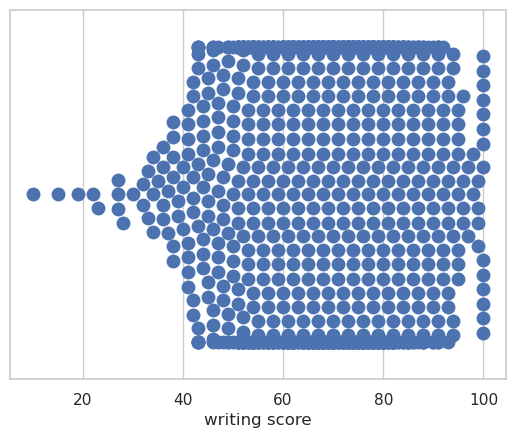

In [65]:
sns.swarmplot(x = 'writing score' , data = df, size = 10)

In [66]:
#sns.stripplot(x = 'writing score' , data = df, size = 10)

<Axes: xlabel='writing score', ylabel='race/ethnicity'>

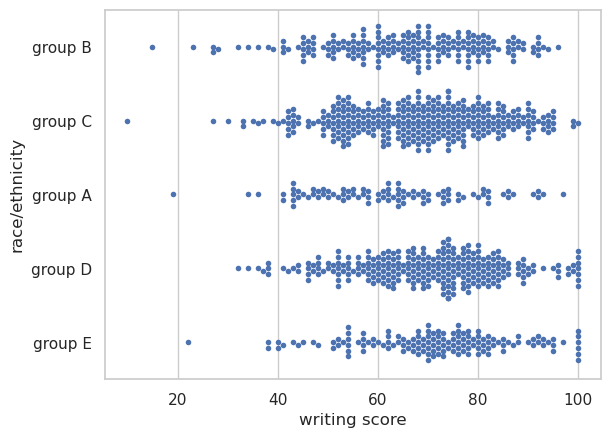

In [68]:
sns.swarmplot(x = 'writing score', y = 'race/ethnicity' , data = df, size = 4 )

<Axes: xlabel='writing score', ylabel='race/ethnicity'>

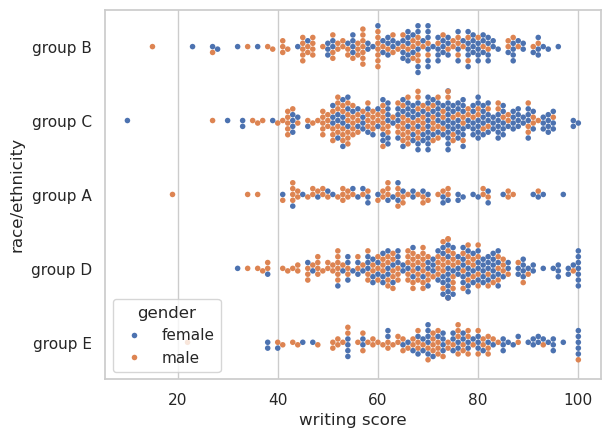

In [69]:
sns.swarmplot(x = 'writing score', y = 'race/ethnicity' , data = df, size = 4 , hue = 'gender')